In [ ]:
# Si no tiene scikit-image instalada ejecutar la celda siguiente
# pip install scikit-image

In [11]:
# Importaciones
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import os
import math
import glob
import shutil
import random
import time
import copy
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score


In [13]:
# ============================================================
# CONFIGURACIÓN DE PYTORCH, GPU Y RUTAS DEL PROYECTO
# FLUJO: LOCAL PRIMERO → FALLBACK A GOOGLE DRIVE
# ============================================================

SEED_GLOBAL = 42

def fijar_semillas(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

fijar_semillas(SEED_GLOBAL)

print("PyTorch version:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU detectada:", torch.cuda.get_device_name(0))
    device = torch.device("cuda")
else:
    print("PyTorch NO detectó GPU. El notebook correrá en CPU.")
    device = torch.device("cpu")

print("Dispositivo usado:", device)


# ============================================================
# FUNCIONES AUXILIARES PARA DETECTAR DATASET
# ============================================================

EXTENSIONES_IMG = ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.pgm", "*.tif", "*.tiff"]

def contar_imagenes(carpeta):
    total = 0
    for ext in EXTENSIONES_IMG:
        total += len(glob.glob(os.path.join(carpeta, ext)))
    return total


def dataset_valido(ruta_proyecto):
    """
    Verifica si una ruta de proyecto contiene un dataset completo:

    ruta_proyecto/
    └── dataset/
        ├── cover/
        ├── stego_7/
        └── stego_15/

    Además exige que las carpetas tengan imágenes.
    """

    ruta_proyecto = os.path.abspath(os.path.expanduser(ruta_proyecto))

    base = os.path.join(ruta_proyecto, "dataset")
    cover = os.path.join(base, "cover")
    stego_7 = os.path.join(base, "stego_7")
    stego_15 = os.path.join(base, "stego_15")

    carpetas_existen = (
        os.path.isdir(base)
        and os.path.isdir(cover)
        and os.path.isdir(stego_7)
        and os.path.isdir(stego_15)
    )

    if not carpetas_existen:
        return False

    hay_imagenes = (
        contar_imagenes(cover) > 0
        and contar_imagenes(stego_7) > 0
        and contar_imagenes(stego_15) > 0
    )

    return hay_imagenes


def buscar_primera_ruta_valida(rutas_candidatas):
    """
    Recorre una lista de posibles rutas de proyecto y retorna la primera
    que tenga el dataset completo.
    """

    for ruta in rutas_candidatas:
        ruta_normalizada = os.path.abspath(os.path.expanduser(ruta))

        if dataset_valido(ruta_normalizada):
            return ruta_normalizada

    return None


# ============================================================
# 1. INTENTAR USAR DATASET LOCAL
# ============================================================

# IMPORTANTE:
# Cada ruta de esta lista debe apuntar a la carpeta que contiene "dataset",
# NO directamente a la carpeta dataset.
#
# Ejemplo correcto:
# C:/Users/usuario/Documents/proyecto_cripto/
# └── dataset/
#     ├── cover/
#     ├── stego_7/
#     └── stego_15/

RUTAS_LOCALES_CANDIDATAS = [
    ".",                         # Carpeta actual del notebook
    "./proyecto-cripto",          # Subcarpeta local opcional
    "/content",                   # Local temporal de Colab
    "/content/proyecto_cripto",    # Subcarpeta local en Colab

    # Si corres en Windows, puedes agregar tu ruta local aquí:
    r"C:\Users\m.amorocho\proyecto-cripto",

    # Si corres en Linux/Mac, puedes agregar tu ruta local aquí:
    # "/home/tu_usuario/proyecto_cripto",
]

RUTA_PROYECTO = buscar_primera_ruta_valida(RUTAS_LOCALES_CANDIDATAS)
ORIGEN_DATASET = "local"


# ============================================================
# 2. SI NO HAY DATASET LOCAL, USAR GOOGLE DRIVE
# ============================================================

if RUTA_PROYECTO is None:
    print("\nNo se encontró un dataset local válido.")
    print("Intentando usar Google Drive como fallback...")

    try:
        #from google.colab import drive
        #drive.mount('/content/drive')

        RUTAS_DRIVE_CANDIDATAS = [
            "/content/drive/MyDrive",
            "/content/drive/MyDrive/Cripto",
            "/content/drive/MyDrive/proyecto_cripto",
        ]

        RUTA_PROYECTO = buscar_primera_ruta_valida(RUTAS_DRIVE_CANDIDATAS)
        ORIGEN_DATASET = "Google Drive"

    except Exception as error:
        raise RuntimeError(
            "No se encontró dataset local y tampoco fue posible montar Google Drive.\n"
            f"Error original: {error}"
        )


# ============================================================
# 3. VALIDACIÓN FINAL
# ============================================================

if RUTA_PROYECTO is None:
    raise FileNotFoundError(
        "No se encontró un dataset válido ni en local ni en Google Drive.\n\n"
        "Revisa que exista una estructura como esta:\n"
        "RUTA_PROYECTO/\n"
        "└── dataset/\n"
        "    ├── cover/\n"
        "    ├── stego_7/\n"
        "    └── stego_15/\n\n"
        "Además, cada carpeta debe contener imágenes."
    )


# ============================================================
# 4. DEFINICIÓN DE RUTAS GLOBALES DEL NOTEBOOK
# ============================================================

directorio_base = os.path.join(RUTA_PROYECTO, "dataset")
directorio_cover = os.path.join(directorio_base, "cover")
directorio_stego_7 = os.path.join(directorio_base, "stego_7")
directorio_stego_15 = os.path.join(directorio_base, "stego_15")
directorio_bossbase = os.path.join(RUTA_PROYECTO, "bossbase_completo", "BOSSbase_1.01")


# ============================================================
# 5. RESUMEN DE CONFIGURACIÓN
# ============================================================

print("\nDataset configurado correctamente.")
print(f"Origen del dataset: {ORIGEN_DATASET}")
print(f"RUTA_PROYECTO:      {RUTA_PROYECTO}")

print("\nRutas usadas:")
print(f"directorio_base:    {directorio_base}")
print(f"directorio_cover:   {directorio_cover}")
print(f"directorio_stego_7: {directorio_stego_7}")
print(f"directorio_stego_15:{directorio_stego_15}")

print("\nCantidad de imágenes detectadas:")
print(f"cover:              {contar_imagenes(directorio_cover)} imágenes")
print(f"stego_7:            {contar_imagenes(directorio_stego_7)} imágenes")
print(f"stego_15:           {contar_imagenes(directorio_stego_15)} imágenes")

PyTorch version: 2.7.1+cu118
CUDA disponible: True
GPU detectada: NVIDIA GeForce RTX 4090
Dispositivo usado: cuda

Dataset configurado correctamente.
Origen del dataset: local
RUTA_PROYECTO:      c:\Users\m.amorocho\proyecto-cripto

Rutas usadas:
directorio_base:    c:\Users\m.amorocho\proyecto-cripto\dataset
directorio_cover:   c:\Users\m.amorocho\proyecto-cripto\dataset\cover
directorio_stego_7: c:\Users\m.amorocho\proyecto-cripto\dataset\stego_7
directorio_stego_15:c:\Users\m.amorocho\proyecto-cripto\dataset\stego_15

Cantidad de imágenes detectadas:
cover:              1000 imágenes
stego_7:            1000 imágenes
stego_15:           1000 imágenes


# **Fase 1: Implementaciones de Matriz Embedding y Extracciones de Mensajes**

## **1.1. Código Hamming (7,4)**

### **1.1.1. Implementación de Matrix Embedding con Código Hamming (7,4)**

El objetivo del Matrix Embedding es minimizar la cantidad de modificaciones necesarias en la imagen de cobertura, reduciendo así la distorsión estadística. Utilizando un código Hamming (7,4), podemos ocultar 3 bits de información secreta en un bloque de 7 píxeles alterando, como máximo, un solo bit menos significativo (LSB).

Matemáticamente, definimos la matriz de comprobación de paridad $H$ de dimensiones $3 \times 7$. Para un bloque de píxeles $x$, calculamos su síndrome actual. Si la diferencia entre el mensaje secreto y el síndrome actual no es nula, el vector resultante nos indica exactamente el índice de la columna en $H$ (y por ende, el píxel) que debe ser modificado para que el nuevo síndrome coincida con el secreto.

In [14]:
def embed_hamming_7_3(pixels_block, secret_bits):
    """
    Oculta 3 bits secretos en un bloque de 7 píxeles.
    pixels_block: array de numpy con 7 valores (ej. [150, 151, 149...])
    secret_bits: array de numpy con 3 bits (ej. [1, 0, 1])
    """
    # 1. Matriz de paridad H para Hamming (7,4)
    H = np.array([
        [0, 0, 0, 1, 1, 1, 1],
        [0, 1, 1, 0, 0, 1, 1],
        [1, 0, 1, 0, 1, 0, 1]
    ])

    # 2. Extraer los LSB (Bits Menos Significativos) del bloque de píxeles
    x = pixels_block % 2

    # 3. Calcular el síndrome actual: s_current = H * x^T (mod 2)
    s_current = np.dot(H, x) % 2

    # 4. Calcular la diferencia con el secreto que queremos: d = secret - s_current (mod 2)
    d = (secret_bits - s_current) % 2

    # 5. Encontrar qué píxel debemos cambiar
    # Convertimos el vector 'd' a un número entero (que coincide con la columna en H)
    index_to_change = d[0]*4 + d[1]*2 + d[2]*1

    modified_pixels = pixels_block.copy()

    # Si el índice es 0, la imagen ya tiene el mensaje por pura casualidad (¡No hacemos nada!)
    # Si es > 0, alteramos el LSB del píxel en la posición correspondiente
    if index_to_change > 0:
        idx = index_to_change - 1

        # Invertir el LSB: si es par suma 1, si es impar resta 1
        if modified_pixels[idx] % 2 == 0:
            modified_pixels[idx] += 1
        else:
            modified_pixels[idx] -= 1

    return modified_pixels

## **1.1.2. Extracción del Mensaje con Código Hamming (7,4)**

La principal ventaja de este esquema es la eficiencia en la recuperación. Para extraer el mensaje de la imagen stego, el receptor no necesita conocer la imagen original. Basta con extraer los LSB de los bloques de 7 píxeles y multiplicarlos por la misma matriz de comprobación de paridad $H$. El síndrome resultante será exactamente el mensaje secreto incrustado.

In [15]:
def extract_hamming_7_3(stego_pixels_block):
    """
    Extrae los 3 bits secretos ocultos en un bloque de 7 píxeles stego.
    stego_pixels_block: array de numpy con 7 valores modificados.
    """
    H = np.array([
        [0, 0, 0, 1, 1, 1, 1],
        [0, 1, 1, 0, 0, 1, 1],
        [1, 0, 1, 0, 1, 0, 1]
    ])

    # 1. Extraer los LSB del bloque stego
    x_stego = stego_pixels_block % 2

    # 2. El mensaje secreto es simplemente el síndrome del bloque
    extracted_bits = np.dot(H, x_stego) % 2

    return extracted_bits

### **1.1.3. Validación Funcional: Inserción y Extracción con Hamming (7,4)**

Para comprobar la correctitud matemática de las operaciones algebraicas de los síndromes, se diseñó una prueba unitaria aislada. Se inyectó el vector secreto [1, 0, 1] en un bloque de control de 7 píxeles.

In [16]:
# --- Bloque de Prueba Unitaria ---
print("--- Prueba de Funcionamiento ---")
original_pixels = np.array([150, 151, 149, 152, 153, 154, 155])
secret = np.array([1, 0, 1])

print(f"Píxeles originales: {original_pixels}")
print(f"Secreto a ocultar:  {secret}")

# Proceso de embedding
stego_pixels = embed_hamming_7_3(original_pixels, secret)
print(f"Píxeles stego:      {stego_pixels}")

# Proceso de extracción
recovered_secret = extract_hamming_7_3(stego_pixels)
print(f"Secreto recuperado: {recovered_secret}")
print(f"¿Éxito?: {'Sí' if np.array_equal(secret, recovered_secret) else 'No'}")

--- Prueba de Funcionamiento ---
Píxeles originales: [150 151 149 152 153 154 155]
Secreto a ocultar:  [1 0 1]
Píxeles stego:      [150 151 149 152 153 155 155]
Secreto recuperado: [1 0 1]
¿Éxito?: Sí


Como se evidencia en los resultados de ejecución, el algoritmo modificó de manera exitosa un único píxel (pasando el penúltimo valor de 154 a 155) para satisfacer la matriz de paridad. Posteriormente, la función de extracción ciega recuperó el secreto original en su totalidad, validando la integridad del diseño algorítmico y demostrando la eficiencia del Matrix Embedding de primer orden.

## **1.2. Código (15,11)**

### **1.2.1. Escalamiento a Matrix Embedding con Hamming (15,11)**

Para analizar un escenario de mayor eficiencia de inserción, implementamos el código Hamming (15,11). En esta configuración, la matriz de comprobación de paridad $H$ tiene dimensiones de $4 \times 15$. Esto nos permite ocultar 4 bits de información en un bloque de 15 píxeles, realizando como máximo una sola modificación.

Teóricamente, esto ofrece un mejor compromiso (trade-off) entre la carga útil y la distorsión estadística, ya que la probabilidad de alterar un píxel disminuye proporcionalmente en bloques más grandes, lo cual evaluaremos frente a las redes residuales.

In [17]:
def embed_hamming_15_11(pixels_block, secret_bits):
    """
    Oculta 4 bits secretos en un bloque de 15 píxeles usando Matrix Embedding.
    pixels_block: array de numpy con 15 valores (ej. [150, 151, ... 164])
    secret_bits: array de numpy con 4 bits (ej. [1, 0, 1, 1])
    """
    # 1. Matriz H de 4x15. Las columnas representan los números del 1 al 15 en binario.
    H = np.array([
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1], # Fila de los 8s
        [0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1], # Fila de los 4s
        [0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1], # Fila de los 2s
        [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]  # Fila de los 1s
    ])

    x = pixels_block % 2
    s_current = np.dot(H, x) % 2
    d = (secret_bits - s_current) % 2

    # 2. Encontrar el índice a modificar (conversión de 4 bits a decimal)
    index_to_change = d[0]*8 + d[1]*4 + d[2]*2 + d[3]*1

    modified_pixels = pixels_block.copy()

    # 3. Modificar el píxel correspondiente si es necesario
    if index_to_change > 0:
        idx = index_to_change - 1

        if modified_pixels[idx] % 2 == 0:
            modified_pixels[idx] += 1
        else:
            modified_pixels[idx] -= 1

    return modified_pixels

### **1.2.2. Extracción del Mensaje con Hamming (15,11)**

De manera análoga al esquema de menor orden, la recuperación de los datos incrustados mediante Hamming (15,11) se realiza de forma ciega, lo que significa que el receptor no requiere acceso a la imagen de cobertura original para extraer el payload.

El proceso de extracción consiste en segmentar la imagen stego en bloques independientes de 15 píxeles, aislar sus bits menos significativos (LSB) y calcular el producto punto de este vector contra la matriz de comprobación de paridad $H$ de dimensiones $4 \times 15$. El vector resultante de 4 bits corresponde al síndrome del bloque, el cual, por la propiedad del Matrix Embedding, es matemáticamente equivalente al fragmento del mensaje secreto original.

In [18]:
def extract_hamming_15_11(stego_pixels_block):
    """
    Extrae los 4 bits secretos ocultos en un bloque de 15 píxeles stego.
    """
    H = np.array([
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1],
        [0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1],
        [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
    ])

    x_stego = stego_pixels_block % 2
    extracted_bits = np.dot(H, x_stego) % 2

    return extracted_bits

### **Validación Funcional: Inserción y Extracción con Hamming (15,11)**

De forma equivalente, se evaluó el comportamiento del esquema de mayor orden. Al incrustar un payload de 4 bits ([1, 1, 0, 1]) en un bloque continuo de 15 píxeles, el motor de inserción determinó matemáticamente que solo era necesario alterar un píxel (modificando el valor 132 por 133) para que el nuevo síndrome del bloque coincidiera exactamente con el secreto.


In [19]:
# --- Bloque de Prueba Unitaria ---
print("--- Prueba Hamming (15,11) ---")
original_pixels_15 = np.array([120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134])
secret_4bits = np.array([1, 1, 0, 1])

stego_pixels_15 = embed_hamming_15_11(original_pixels_15, secret_4bits)
recovered_secret_15 = extract_hamming_15_11(stego_pixels_15)

print(f"Píxeles originales: {original_pixels_15}")
print(f"Secreto a ocultar:  {secret_4bits}")
print(f"Píxeles stego:      {stego_pixels_15}")
print(f"Secreto recuperado: {recovered_secret_15}")
print(f"¿Éxito?: {'Sí' if np.array_equal(secret_4bits, recovered_secret_15) else 'No'}")

--- Prueba Hamming (15,11) ---
Píxeles originales: [120 121 122 123 124 125 126 127 128 129 130 131 132 133 134]
Secreto a ocultar:  [1 1 0 1]
Píxeles stego:      [120 121 122 123 124 125 126 127 128 129 130 131 133 133 134]
Secreto recuperado: [1 1 0 1]
¿Éxito?: Sí


La recuperación demostró ser 100% precisa, confirmando que la lógica de prevención de desbordamientos de rango para los LSB funciona sin corromper la información subyacente.

## **1.3. Conclusión de la Fase 1: Implementación de Algoritmos**

La primera fase experimental del proyecto confirma que la implementación de los códigos Hamming (7,4) y (15,11) en el dominio espacial es computacionalmente precisa. Ambos algoritmos logran ocultar flujos de bits minimizando la tasa de alteración a un máximo estricto de una modificación por bloque, lo cual garantiza la alta eficiencia de incrustación que fundamenta la técnica de Matrix Embedding.

Al validar que la matemática de los síndromes opera correctamente y que los algoritmos manejan la inversión de los bits menos significativos (LSB) sin inducir errores de rango en la escala de grises, se establece una base algorítmica robusta. Esto permite dar por concluida la implementación criptográfica y avanzar con garantías hacia el procesamiento de imágenes a gran escala, la generación del corpus experimental y la posterior confrontación contra el esteganálisis basado en redes residuales.

# **Fase 2: Procesamiento de Imágenes y Generación de Dataset**

## **2.1. Motor de Inserción y Procesamiento de Imágenes**

Para escalar la técnica de Matrix Embedding a imágenes completas, se desarrolló un motor de procesamiento que opera en el dominio espacial. El flujo de trabajo consiste en:

1. Conversión a Escala de Grises: Se trabaja sobre un solo canal para simplificar la demostración de la eficiencia de los códigos Hamming.

2. Serialización del Payload: El mensaje secreto se convierte en un flujo de bits aleatorios.

3. Segmentación por Bloques: La imagen se aplanada y se divide en bloques de tamaño $n$ (7 o 15), aplicando la modificación de LSB correspondiente según el síndrome calculado.

4. Preservación de Integridad: Los resultados se almacenan en formato PNG (Lossless) para evitar que la compresión por transformada de coseno (como en JPEG) destruya la información oculta en los bits menos significativos.

In [20]:
def process_full_image(image_path, n_type=7):
    """
    Carga una imagen, oculta un mensaje aleatorio y la guarda.
    n_type: 7 para Hamming(7,4) o 15 para Hamming(15,11)
    """
    # 1. Cargar imagen en escala de grises
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error: No se pudo cargar {image_path}")
        return

    h, w = img.shape
    pixels = img.flatten() # Aplanar para iterar fácilmente

    # Definir parámetros según el tipo de Hamming seleccionado
    if n_type == 7:
        n, k_bits = 7, 3
        embed_func = embed_hamming_7_3
    else:
        n, k_bits = 15, 4
        embed_func = embed_hamming_15_11

    # 2. Calcular capacidad y generar secreto aleatorio
    num_blocks = len(pixels) // n
    total_secret_bits = num_blocks * k_bits
    # Generamos un secreto aleatorio para la prueba (simulando datos cifrados)
    secret_payload = np.random.randint(0, 2, total_secret_bits)

    # 3. Iterar por bloques y aplicar embedding
    stego_pixels = pixels.copy()
    for i in range(num_blocks):
        start_px = i * n
        start_bit = i * k_bits

        block = pixels[start_px : start_px + n]
        bits = secret_payload[start_bit : start_bit + k_bits]

        stego_pixels[start_px : start_px + n] = embed_func(block, bits)

    # 4. Reconstruir la imagen 2D
    stego_img = stego_pixels.reshape((h, w))

    # 5. Guardar resultado en formato PNG (Crucial: NO usar JPG)
    output_name = f"stego_{n_type}_{os.path.basename(image_path)}"
    cv2.imwrite(output_name, stego_img)

    print(f"Imagen generada con éxito: {output_name}")
    print(f"Bits ocultos: {total_secret_bits} | Eficiencia: 1 cambio máx por bloque de {n} px.")
    return output_name

## **2.2. Ejecución y Análisis de Capacidad (Prueba Piloto)**

Para validar el funcionamiento del motor de inserción y observar el comportamiento de las tasas de incrustación espacial sin depender de recursos externos, se genera dinámicamente una imagen de control sintética de $256 \times 256$ píxeles.

Sobre esta matriz controlada se aplican ambos esquemas de Matrix Embedding, haciendo evidente el compromiso inherente entre la longitud del bloque y la capacidad de carga útil (payload):

* Esquema Hamming (7,4): Tasa teórica de $\approx 0.43$ bits por píxel.

* Esquema Hamming (15,11): Tasa teórica de $\approx 0.27$ bits por píxel.

Esta prueba aísla la lógica matemática de los síndromes antes de escalar el procesamiento al corpus completo.

In [21]:
print("--- 1. Generación de Imagen de Control ---")
# Creamos una imagen sintética de 256x256 con ruido aleatorio (simulando texturas)
imagen_sintetica = np.random.randint(0, 256, (256, 256), dtype=np.uint8)
ruta_prueba = 'imagen_de_prueba_sintetica.png'
cv2.imwrite(ruta_prueba, imagen_sintetica)
print(f"Imagen temporal creada: {ruta_prueba} (Dimensiones: 256x256)")

print("\n--- 2. Prueba de Inserción con Hamming (7,4) ---")
img_7_path = process_full_image(ruta_prueba, n_type=7)

print("\n--- 3. Prueba de Inserción con Hamming (15,11) ---")
img_15_path = process_full_image(ruta_prueba, n_type=15)

--- 1. Generación de Imagen de Control ---
Imagen temporal creada: imagen_de_prueba_sintetica.png (Dimensiones: 256x256)

--- 2. Prueba de Inserción con Hamming (7,4) ---
Imagen generada con éxito: stego_7_imagen_de_prueba_sintetica.png
Bits ocultos: 28086 | Eficiencia: 1 cambio máx por bloque de 7 px.

--- 3. Prueba de Inserción con Hamming (15,11) ---
Imagen generada con éxito: stego_15_imagen_de_prueba_sintetica.png
Bits ocultos: 17476 | Eficiencia: 1 cambio máx por bloque de 15 px.


El código (7,4) permite ocultar un volumen significativamente mayor de información que el código (15,11) para las mismas dimensiones espaciales. Sin embargo, esta mayor capacidad está intrínsecamente ligada a una mayor densidad de modificaciones, lo que se evaluará estadísticamente en la siguiente fase.

In [22]:
# Limpieza de Artefactos de Prueba
archivos_a_eliminar = [ruta_prueba, img_7_path, img_15_path]

print("--- Intentando eliminar artefactos de prueba ---")
for archivo in archivos_a_eliminar:
    if os.path.exists(archivo):
        os.remove(archivo)
        print(f"Artefacto temporal eliminado: {archivo}")
    else:
        print(f"Artefacto {archivo} no encontrado (ya eliminado o nunca creado).")


# Verificar que los archivos hayan sido eliminados
print("\n--- Verificación de eliminación ---")
for archivo in archivos_a_eliminar:
    if not os.path.exists(archivo):
        print(f"Verificado: {archivo} ha sido eliminado exitosamente.")
    else:
        print(f"Error: {archivo} aún existe.")

--- Intentando eliminar artefactos de prueba ---
Artefacto temporal eliminado: imagen_de_prueba_sintetica.png
Artefacto temporal eliminado: stego_7_imagen_de_prueba_sintetica.png
Artefacto temporal eliminado: stego_15_imagen_de_prueba_sintetica.png

--- Verificación de eliminación ---
Verificado: imagen_de_prueba_sintetica.png ha sido eliminado exitosamente.
Verificado: stego_7_imagen_de_prueba_sintetica.png ha sido eliminado exitosamente.
Verificado: stego_15_imagen_de_prueba_sintetica.png ha sido eliminado exitosamente.


## **2.3. Adquisición y Preparación del Dataset BOSSBase**

Para garantizar la validez científica del esteganálisis, se optó por utilizar BOSSBase 1.01 (Break Our Steganographic System), un corpus estandarizado en la literatura de seguridad de la información. Este conjunto de datos consta de imágenes en formato PGM (Portable Gray Map) con texturas ricas y ruido de sensor natural, lo que las hace ideales como imágenes de cobertura.

Mediante el siguiente bloque, se automatiza la descarga directa del repositorio académico y la extracción de las muestras en el entorno de ejecución, conformando el directorio raíz de imágenes limpias (cover) que alimentará el motor de inserción de Matrix Embedding.

In [23]:
# ============================================================
# SE OMITE DESCARGA / EXTRACCIÓN / CLASIFICACIÓN DE BOSSBASE
# ============================================================
# El notebook ahora usa el dataset ya generado en:
#   directorio_base/cover
#   directorio_base/stego_7
#   directorio_base/stego_15

print("Se omite la descarga y clasificación porque el dataset ya existe.")
print(f"Dataset base: {directorio_base}")
print(f"Cover:        {contar_imagenes(directorio_cover)} imágenes")
print(f"Stego 7:      {contar_imagenes(directorio_stego_7)} imágenes")
print(f"Stego 15:     {contar_imagenes(directorio_stego_15)} imágenes")


Se omite la descarga y clasificación porque el dataset ya existe.
Dataset base: c:\Users\m.amorocho\proyecto-cripto\dataset
Cover:        1000 imágenes
Stego 7:      1000 imágenes
Stego 15:     1000 imágenes


## **2.4. Generación del Corpus Esteganográfico (Procesamiento por Lotes)**

Una vez consolidado el directorio base con las imágenes oficiales del corpus BOSSBase, se procede a la generación masiva de los conjuntos de datos modificados.

Se definió una función iterativa que recorre la totalidad de las imágenes de cobertura, extrae sus matrices de píxeles y aplica, de manera independiente, las rutinas de Matrix Embedding para los códigos Hamming (7,4) y (15,11). Las imágenes resultantes se exportan forzosamente en formato PNG (Portable Network Graphics) dentro de sus respectivos directorios (stego_7 y stego_15). Esta conversión de formato es una medida crítica para asegurar una compresión sin pérdidas (lossless), previniendo así la destrucción de los bits menos significativos (LSB) que contienen el payload incrustado.

In [24]:
# --- 1. Definición de la Función Principal ---
def generate_stego_dataset(input_dir, output_dir_7, output_dir_15, max_images=None):
    """
    Recorre una carpeta de imágenes originales y genera dos datasets stego completos.
    """
    os.makedirs(output_dir_7, exist_ok=True)
    os.makedirs(output_dir_15, exist_ok=True)

    image_paths = glob.glob(os.path.join(input_dir, '*.*'))

    if max_images:
        image_paths = image_paths[:max_images]

    print(f"Iniciando procesamiento de {len(image_paths)} imágenes. Esto puede tardar varios minutos...")

    for idx, img_path in enumerate(image_paths):
        filename = os.path.basename(img_path)
        name_without_ext = os.path.splitext(filename)[0]
        output_name = f"{name_without_ext}.png" # Forzamos PNG sin pérdidas

        path_out_7 = os.path.join(output_dir_7, output_name)
        path_out_15 = os.path.join(output_dir_15, output_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        h, w = img.shape
        pixels = img.flatten()

        # --- Procesamiento Hamming (7,4) ---
        num_blocks_7 = len(pixels) // 7
        secret_7 = np.random.randint(0, 2, num_blocks_7 * 3)
        stego_pixels_7 = pixels.copy()

        for i in range(num_blocks_7):
            start_px, start_bit = i * 7, i * 3
            block = pixels[start_px : start_px + 7]
            bits = secret_7[start_bit : start_bit + 3]
            stego_pixels_7[start_px : start_px + 7] = embed_hamming_7_3(block, bits)

        cv2.imwrite(path_out_7, stego_pixels_7.reshape((h, w)))

        # --- Procesamiento Hamming (15,11) ---
        num_blocks_15 = len(pixels) // 15
        secret_15 = np.random.randint(0, 2, num_blocks_15 * 4)
        stego_pixels_15 = pixels.copy()

        for i in range(num_blocks_15):
            start_px, start_bit = i * 15, i * 4
            block = pixels[start_px : start_px + 15]
            bits = secret_15[start_bit : start_bit + 4]
            stego_pixels_15[start_px : start_px + 15] = embed_hamming_15_11(block, bits)

        cv2.imwrite(path_out_15, stego_pixels_15.reshape((h, w)))

        # Imprimir progreso cada 100 imágenes para no saturar la consola
        if (idx + 1) % 100 == 0 or (idx + 1) == len(image_paths):
            print(f"Progreso: {idx + 1}/{len(image_paths)} imágenes procesadas y guardadas.")

    print("\n¡Generación del corpus stego finalizada con éxito!")

### **2.4.1. Procesamiento Exhaustivo del Corpus BOSSBase**

Habiendo validado la operatividad del flujo de directorios y la integridad matemática del motor de inserción en la prueba piloto, se procede con el procesamiento masivo del dataset fotográfico oficial (BOSSBase 1.01).

El siguiente bloque de código ejecuta el pipeline iterativo sobre la totalidad de las 10,000 muestras de cobertura. El algoritmo lee secuencialmente las rutas, aplica de manera independiente las incrustaciones de Matrix Embedding para los códigos Hamming (7,4) y (15,11), y exporta las imágenes stego resultantes en los directorios correspondientes. Se fuerza la salida a formato PNG para garantizar una compresión sin pérdidas (lossless) y preservar los LSB. Para auditar la estabilidad computacional del entorno de ejecución, el sistema reporta el progreso en lotes. La culminación de este proceso consolida el corpus definitivo que alimentará la fase de entrenamiento del modelo de esteganálisis residual.

In [25]:
# --- Rutas del corpus ya existente ---
directorio_originales = directorio_cover

print("Rutas configuradas:")
print(f"Originales / cover: {directorio_originales}")
print(f"Stego 7:            {directorio_stego_7}")
print(f"Stego 15:           {directorio_stego_15}")


Rutas configuradas:
Originales / cover: c:\Users\m.amorocho\proyecto-cripto\dataset\cover
Stego 7:            c:\Users\m.amorocho\proyecto-cripto\dataset\stego_7
Stego 15:           c:\Users\m.amorocho\proyecto-cripto\dataset\stego_15


In [26]:
# ============================================================
# NO REGENERAR DATASET STEGO SI YA EXISTE
# ============================================================

REGENERAR_STEGO = False

if REGENERAR_STEGO:
    generate_stego_dataset(
        input_dir=directorio_originales,
        output_dir_7=directorio_stego_7,
        output_dir_15=directorio_stego_15
    )
else:
    print("Se omite la generación de imágenes stego porque el dataset ya existe.")
    print(f"Cover:    {contar_imagenes(directorio_cover)} imágenes")
    print(f"Stego 7:  {contar_imagenes(directorio_stego_7)} imágenes")
    print(f"Stego 15: {contar_imagenes(directorio_stego_15)} imágenes")


Se omite la generación de imágenes stego porque el dataset ya existe.
Cover:    1000 imágenes
Stego 7:  1000 imágenes
Stego 15: 1000 imágenes


# **Fase 3: Entrenamiento del Modelo de esteganálisis**

## **3.1. Construcción del Pipeline de Datos y Partición**

Para la fase de Deep Learning, se utiliza PyTorch con un `Dataset` personalizado y `DataLoader`, de forma que las imágenes de cobertura y las imágenes stego se leen directamente desde la estructura de carpetas ya generada. Esta modificación evita volver a descargar o clasificar BOSSBase en cada ejecución.

Para garantizar una evaluación rigurosa, se implementa una partición estratificada del corpus en dos subconjuntos: 80% para entrenamiento y 20% para validación, fijando una semilla aleatoria para asegurar reproducibilidad.

Consideración crítica: las imágenes se cargan en escala de grises y, si es necesario ajustar tamaño, se usa interpolación por vecino más cercano para evitar alteraciones innecesarias en los bits menos significativos, donde reside el payload de los códigos Hamming.


In [27]:
# ============================================================
# VERIFICACIÓN / CONVERSIÓN OPCIONAL DE COVER A PNG
# ============================================================

print("--- Verificando formato del corpus cover ---")

rutas_png = glob.glob(os.path.join(directorio_cover, "*.png"))
rutas_pgm = glob.glob(os.path.join(directorio_cover, "*.pgm"))

print(f"Imágenes PNG encontradas en cover: {len(rutas_png)}")
print(f"Imágenes PGM encontradas en cover: {len(rutas_pgm)}")

# Keras ya no se usa, pero para mantener compatibilidad con el resto del análisis
# conviene tener PNG disponibles. No se borran los PGM originales.
if len(rutas_png) == 0 and len(rutas_pgm) > 0:
    print("No se encontraron PNG en cover. Convirtiendo PGM a PNG...")

    for ruta in rutas_pgm:
        img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            nueva_ruta = os.path.splitext(ruta)[0] + ".png"
            cv2.imwrite(nueva_ruta, img)

    rutas_png = glob.glob(os.path.join(directorio_cover, "*.png"))
    print(f"Conversión finalizada. PNG disponibles en cover: {len(rutas_png)}")
else:
    print("No es necesario convertir. El corpus cover ya tiene imágenes PNG o PyTorch leerá PGM directamente.")


--- Verificando formato del corpus cover ---
Imágenes PNG encontradas en cover: 1000
Imágenes PGM encontradas en cover: 0
No es necesario convertir. El corpus cover ya tiene imágenes PNG o PyTorch leerá PGM directamente.


In [28]:
print("--- 1. Definición de Parámetros Dinámicos ---")

# Se usan las rutas definidas en la celda de configuración.
# NO reasignar directorio_base a "./dataset/".

lista_imagenes = []
for ext in EXTENSIONES_IMG:
    lista_imagenes.extend(glob.glob(os.path.join(directorio_cover, ext)))
lista_imagenes = sorted(lista_imagenes)

if lista_imagenes:
    imagen_muestra = cv2.imread(lista_imagenes[0], cv2.IMREAD_GRAYSCALE)
    ALTO_IMG, ANCHO_IMG = imagen_muestra.shape
else:
    ALTO_IMG, ANCHO_IMG = 512, 512

BATCH_SIZE = 32
SEMILLA = 42
VALIDATION_SPLIT = 0.2
NUM_WORKERS = 0  # En Windows/Jupyter es más estable dejarlo en 0.
PIN_MEMORY = (device.type == "cuda")

print(f"Dataset usado: {directorio_base}")
print(f"Dimensiones de entrada configuradas a: {ALTO_IMG}x{ANCHO_IMG}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Pin memory: {PIN_MEMORY}")


--- 1. Definición de Parámetros Dinámicos ---
Dataset usado: c:\Users\m.amorocho\proyecto-cripto\dataset
Dimensiones de entrada configuradas a: 512x512
Batch size: 32
Pin memory: True


In [29]:
print("\n--- 2. Partición de Datos con PyTorch (80% Entrenamiento / 20% Validación) ---")

class DatasetEstego(Dataset):
    def __init__(self, rutas, etiquetas, alto, ancho):
        self.rutas = list(rutas)
        self.etiquetas = list(etiquetas)
        self.alto = alto
        self.ancho = ancho

    def __len__(self):
        return len(self.rutas)

    def __getitem__(self, idx):
        ruta = self.rutas[idx]
        etiqueta = self.etiquetas[idx]

        img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"No se pudo leer la imagen: {ruta}")

        # Mantener interpolación nearest para no alterar innecesariamente los LSB.
        if img.shape != (self.alto, self.ancho):
            img = cv2.resize(img, (self.ancho, self.alto), interpolation=cv2.INTER_NEAREST)

        # PyTorch usa formato NCHW. Valores en escala 0-255, igual que el flujo original.
        img = img.astype(np.float32)
        img = torch.from_numpy(img).unsqueeze(0)  # (1, H, W)

        etiqueta = torch.tensor([float(etiqueta)], dtype=torch.float32)
        return img, etiqueta


def listar_imagenes_clase(directorio_clase):
    rutas = []
    for ext in EXTENSIONES_IMG:
        rutas.extend(glob.glob(os.path.join(directorio_clase, ext)))
    return sorted(rutas)


def crear_dataloaders_binarios(directorio_base, class_names, validation_split=0.2, seed=42):
    """
    Crea train_loader y val_loader manteniendo el mapeo:
    class_names[0] -> etiqueta 0
    class_names[1] -> etiqueta 1
    """
    rng = np.random.default_rng(seed)

    rutas_train, etiquetas_train = [], []
    rutas_val, etiquetas_val = [], []

    for etiqueta, clase in enumerate(class_names):
        directorio_clase = os.path.join(directorio_base, clase)
        rutas_clase = listar_imagenes_clase(directorio_clase)

        if len(rutas_clase) == 0:
            raise ValueError(f"No se encontraron imágenes para la clase '{clase}' en {directorio_clase}")

        indices = np.arange(len(rutas_clase))
        rng.shuffle(indices)

        n_val = max(1, int(round(len(indices) * validation_split)))
        idx_val = indices[:n_val]
        idx_train = indices[n_val:]

        rutas_val.extend([rutas_clase[i] for i in idx_val])
        etiquetas_val.extend([etiqueta] * len(idx_val))

        rutas_train.extend([rutas_clase[i] for i in idx_train])
        etiquetas_train.extend([etiqueta] * len(idx_train))

    # Shuffle final para mezclar clases dentro de cada subconjunto.
    orden_train = np.arange(len(rutas_train))
    orden_val = np.arange(len(rutas_val))
    rng.shuffle(orden_train)
    rng.shuffle(orden_val)

    rutas_train = [rutas_train[i] for i in orden_train]
    etiquetas_train = [etiquetas_train[i] for i in orden_train]
    rutas_val = [rutas_val[i] for i in orden_val]
    etiquetas_val = [etiquetas_val[i] for i in orden_val]

    ds_train = DatasetEstego(rutas_train, etiquetas_train, ALTO_IMG, ANCHO_IMG)
    ds_val = DatasetEstego(rutas_val, etiquetas_val, ALTO_IMG, ANCHO_IMG)

    train_loader = DataLoader(
        ds_train,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

    val_loader = DataLoader(
        ds_val,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

    print(f"Clases: {class_names}")
    print(f"Entrenamiento: {len(ds_train)} imágenes")
    print(f"Validación:    {len(ds_val)} imágenes")

    return train_loader, val_loader


train_dataset, val_dataset = crear_dataloaders_binarios(
    directorio_base=directorio_base,
    class_names=['cover', 'stego_15'],
    validation_split=VALIDATION_SPLIT,
    seed=SEMILLA
)



--- 2. Partición de Datos con PyTorch (80% Entrenamiento / 20% Validación) ---
Clases: ['cover', 'stego_15']
Entrenamiento: 1600 imágenes
Validación:    400 imágenes


### **3.1.1. Interpretación del Flujo de Tensores**

La validación inicial del `DataLoader` confirma que PyTorch construye correctamente los tensores requeridos para la red convolucional. A diferencia de TensorFlow/Keras, PyTorch trabaja por defecto con el formato `(batch, canales, alto, ancho)`.


In [30]:
print("\n--- 3. Verificación del DataLoader de PyTorch ---")

imagenes, etiquetas = next(iter(train_dataset))

print(f"\n[Entrenamiento] Forma del lote de imágenes: {imagenes.shape}")
print("Formato esperado en PyTorch: (batch, canales, alto, ancho)")
print(f"[Entrenamiento] Etiquetas del lote (primeras 5): {etiquetas[:5].cpu().numpy().reshape(-1)}")
print(f"[Validación] Tamaño del lote: {BATCH_SIZE}")
print(f"[Validación] Dispositivo de entrenamiento: {device}")



--- 3. Verificación del DataLoader de PyTorch ---

[Entrenamiento] Forma del lote de imágenes: torch.Size([32, 1, 512, 512])
Formato esperado en PyTorch: (batch, canales, alto, ancho)
[Entrenamiento] Etiquetas del lote (primeras 5): [0. 1. 1. 1. 0.]
[Validación] Tamaño del lote: 32
[Validación] Dispositivo de entrenamiento: cuda


- **Inferencia de Clases (['cover', 'stego_15']):** El motor asigna valores binarios basándose en el orden alfabético de los directorios. La clase cover se mapea a la etiqueta 0.0 y la clase stego_15 a la etiqueta 1.0.

- **Topología del Lote ((32, 512, 512, 1)):** Este tensor de cuarto orden define la estructura de entrada:

- **32 (Batch Size):** Representa el número de muestras procesadas en paralelo por cada paso del gradiente.

- **512, 512 (Resolución Espacial):** Confirma la extracción nativa de las dimensiones de BOSSBase sin interpolaciones destructivas.

- **1 (Canales):** Indica la profundidad de intensidad en escala de grises.-

- **Mapeo de Etiquetas:** Se verifica que el vector de salida del lote contenga una distribución estocástica de ceros y unos, confirmando que el proceso de shuffle está operativo y que la red recibirá muestras balanceadas en cada iteración.

## **3.2. Diseño de la Arquitectura Residual**

A diferencia de las tareas tradicionales de visión por computadora, donde el objetivo es extraer características semánticas (bordes, formas, objetos), el esteganálisis requiere identificar alteraciones de altísima frecuencia correspondientes al ruido inducido en los bits menos significativos (LSB).

Para este fin, se diseñó una arquitectura de red neuronal convolucional (CNN) adaptada mediante el uso de bloques residuales. Las conexiones de salto (skip connections) introducidas en estos bloques previenen la degradación del gradiente durante el entrenamiento y permiten que la red retenga las señales débiles del ruido esteganográfico a lo largo de las capas de extracción de características.

La red culmina en una capa de agrupamiento global (Global Average Pooling) seguida de un perceptrón con función de activación sigmoide, optimizada para entregar una predicción binaria continua entre 0 (Cobertura) y 1 (Stego).

In [31]:
# ============================================================
# ARQUITECTURA RESIDUAL EN PYTORCH
# Mantiene la misma idea del modelo original en TensorFlow/Keras:
# - HPF fijo inicial
# - Conv -> BN -> LeakyReLU
# - Bloques residuales
# - AveragePooling
# - SE en los bloques profundos
# - GlobalAveragePooling + Dense(64) + Dropout + salida binaria
# ============================================================

_k1 = np.array([[-1,  2, -1],
                [ 2, -4,  2],
                [-1,  2, -1]], dtype=np.float32) / 4.0

_k2 = np.array([[ 1,  0, -1],
                [ 2,  0, -2],
                [ 1,  0, -1]], dtype=np.float32) / 4.0

_k3 = np.array([[ 1,  2,  1],
                [ 0,  0,  0],
                [-1, -2, -1]], dtype=np.float32) / 4.0

# PyTorch espera pesos de Conv2d como: (out_channels, in_channels, kernel_h, kernel_w)
HPF_WEIGHTS_TORCH = torch.tensor(
    np.stack([_k1, _k2, _k3], axis=0)[:, np.newaxis, :, :],
    dtype=torch.float32
)


class SEBlock(nn.Module):
    def __init__(self, canales, reduccion=8):
        super().__init__()
        canales_intermedios = max(canales // reduccion, 4)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Conv2d(canales, canales_intermedios, kernel_size=1, bias=False)
        self.fc2 = nn.Conv2d(canales_intermedios, canales, kernel_size=1, bias=False)

    def forward(self, x):
        se = self.gap(x)
        se = F.relu(self.fc1(se))
        se = torch.sigmoid(self.fc2(se))
        return x * se


class BloqueResidualEstego(nn.Module):
    def __init__(self, canales_entrada, filtros, usar_se=False):
        super().__init__()

        self.conv1 = nn.Conv2d(canales_entrada, filtros, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(filtros)
        self.act1 = nn.LeakyReLU(negative_slope=0.1, inplace=True)

        self.conv2 = nn.Conv2d(filtros, filtros, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(filtros)

        self.se = SEBlock(filtros) if usar_se else nn.Identity()

        if canales_entrada != filtros:
            self.proyeccion = nn.Sequential(
                nn.Conv2d(canales_entrada, filtros, kernel_size=1, padding=0, bias=False),
                nn.BatchNorm2d(filtros)
            )
        else:
            self.proyeccion = nn.Identity()

        self.act_out = nn.LeakyReLU(negative_slope=0.1, inplace=True)

    def forward(self, x):
        salto = self.proyeccion(x)

        y = self.conv1(x)
        y = self.bn1(y)
        y = self.act1(y)

        y = self.conv2(y)
        y = self.bn2(y)
        y = self.se(y)

        y = y + salto
        y = self.act_out(y)
        return y


class ResNetEstego(nn.Module):
    def __init__(self, nombre_modelo="ResNetEstegoCorregida"):
        super().__init__()
        self.nombre_modelo = nombre_modelo

        self.filtro_hpf_fijo = nn.Conv2d(
            in_channels=1,
            out_channels=3,
            kernel_size=3,
            padding=1,
            bias=False
        )

        with torch.no_grad():
            self.filtro_hpf_fijo.weight.copy_(HPF_WEIGHTS_TORCH)
        self.filtro_hpf_fijo.weight.requires_grad_(False)

        self.bn_hpf = nn.BatchNorm2d(3)

        self.conv_inicial = nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False)
        self.bn_inicial = nn.BatchNorm2d(32)
        self.lrelu_inicial = nn.LeakyReLU(negative_slope=0.1, inplace=True)

        self.res1 = BloqueResidualEstego(32, 32, usar_se=False)
        self.avgpool1 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.res2 = BloqueResidualEstego(32, 64, usar_se=False)
        self.avgpool2 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.res3 = BloqueResidualEstego(64, 128, usar_se=True)
        self.avgpool3 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.res4 = BloqueResidualEstego(128, 128, usar_se=True)

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dense_64 = nn.Linear(128, 64)
        self.dropout_1 = nn.Dropout(p=0.2)
        self.prediccion_stego = nn.Linear(64, 1)

    def forward(self, x):
        # Igual que en TensorFlow: NO se divide entre 255 antes del HPF.
        x = self.filtro_hpf_fijo(x)
        x = torch.clamp(x, min=-3.0, max=3.0)
        x = self.bn_hpf(x)

        x = self.conv_inicial(x)
        x = self.bn_inicial(x)
        x = self.lrelu_inicial(x)

        x = self.res1(x)
        x = self.avgpool1(x)

        x = self.res2(x)
        x = self.avgpool2(x)

        x = self.res3(x)
        x = self.avgpool3(x)

        x = self.res4(x)

        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.dense_64(x))
        x = self.dropout_1(x)

        # Se retornan logits. Para probabilidades se aplica sigmoid fuera del modelo.
        x = self.prediccion_stego(x)
        return x


def contar_parametros(modelo):
    total = sum(p.numel() for p in modelo.parameters())
    entrenables = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
    return total, entrenables


def construir_modelo_estego(nombre_modelo="ResNetEstegoCorregida"):
    modelo = ResNetEstego(nombre_modelo=nombre_modelo).to(device)
    return modelo


print("--- Ensamblando Arquitectura PyTorch para Hamming (15,11) ---")

model_resnet = construir_modelo_estego(
    nombre_modelo="ResNetEstego_Hamming15_Corregida"
)

print(model_resnet)
total_params, trainable_params = contar_parametros(model_resnet)
print(f"\nParámetros totales: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")


--- Ensamblando Arquitectura PyTorch para Hamming (15,11) ---
ResNetEstego(
  (filtro_hpf_fijo): Conv2d(1, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn_hpf): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_inicial): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn_inicial): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (lrelu_inicial): LeakyReLU(negative_slope=0.1, inplace=True)
  (res1): BloqueResidualEstego(
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act1): LeakyReLU(negative_slope=0.1, inplace=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (se): Identity()
    (proy

### **3.3. Configuración y Protocolo de Entrenamiento**

Una vez consolidada la arquitectura y el flujo de datos, se establece el protocolo de optimización. El entrenamiento se rige por una función de pérdida de entropía cruzada binaria (Binary Crossentropy), adecuada para la naturaleza del problema.  

Para garantizar la convergencia y mitigar el riesgo de sobreajuste (overfitting) en un escenario de señales débiles como el esteganálisis, se integran mecanismos de regularización dinámica (callbacks):  

* Early Stopping: Monitorea la pérdida en el conjunto de validación y detiene el proceso si no hay una mejora significativa tras un número determinado de épocas.

* ReduceLROnPlateau: Reduce el factor de aprendizaje (Learning Rate) cuando la pérdida se estanca, permitiendo una búsqueda más fina del mínimo global en el espacio de parámetros.

* Model Checkpoint: Almacena automáticamente los pesos de la época que reporte el mejor desempeño en validación.

In [32]:
# ============================================================
# FUNCIONES DE ENTRENAMIENTO EN PYTORCH
# Equivalentes a model.compile(), model.fit(), callbacks y evaluate()
# ============================================================

USAR_AMP = (device.type == "cuda")

class HistoryTorch:
    def __init__(self):
        self.history = {
            "loss": [],
            "accuracy": [],
            "auc": [],
            "val_loss": [],
            "val_accuracy": [],
            "val_auc": []
        }


def calcular_auc_seguro(y_true, y_prob):
    y_true = np.asarray(y_true).reshape(-1)
    y_prob = np.asarray(y_prob).reshape(-1)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return roc_auc_score(y_true, y_prob)


def calcular_metricas_desde_arrays(y_true, y_prob):
    y_true = np.asarray(y_true).reshape(-1)
    y_prob = np.asarray(y_prob).reshape(-1)
    y_pred = (y_prob > 0.5).astype(int)

    accuracy = np.mean(y_pred == y_true.astype(int))
    auc_value = calcular_auc_seguro(y_true, y_prob)

    return accuracy, auc_value


def evaluar_modelo_pytorch(modelo, dataloader, criterio):
    modelo.eval()

    total_loss = 0.0
    total_muestras = 0
    y_true_total = []
    y_prob_total = []

    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            with autocast(enabled=USAR_AMP):
                logits = modelo(x_batch)
                loss = criterio(logits, y_batch)

            batch_size = x_batch.size(0)
            total_loss += loss.item() * batch_size
            total_muestras += batch_size

            probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
            labels = y_batch.detach().cpu().numpy().reshape(-1)

            y_prob_total.extend(probs)
            y_true_total.extend(labels)

    loss_promedio = total_loss / max(total_muestras, 1)
    accuracy, auc_value = calcular_metricas_desde_arrays(y_true_total, y_prob_total)

    return {
        "loss": loss_promedio,
        "accuracy": accuracy,
        "auc": auc_value
    }


def imprimir_pred_stats(modelo, dataloader, nombre="validacion", n_batches=4):
    modelo.eval()
    probs_total = []

    with torch.no_grad():
        for i, (x_batch, _) in enumerate(dataloader):
            if i >= n_batches:
                break

            x_batch = x_batch.to(device, non_blocking=True)

            with autocast(enabled=USAR_AMP):
                logits = modelo(x_batch)

            probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
            probs_total.extend(probs)

    probs_total = np.array(probs_total)

    print(
        f"\n[{nombre}] "
        f"pred_mean={probs_total.mean():.4f} | "
        f"pred_min={probs_total.min():.4f} | "
        f"pred_max={probs_total.max():.4f} | "
        f"% pred > 0.5 = {(probs_total > 0.5).mean() * 100:.2f}%"
    )


def entrenar_modelo_pytorch(
    modelo,
    train_loader,
    val_loader,
    nombre_modelo,
    ruta_checkpoint,
    epocas=30,
    lr=3e-4,
    patience_early=6,
    patience_lr=3,
    factor_lr=0.5,
    min_lr=1e-6,
    l2_dense=1e-5
):
    criterio = nn.BCEWithLogitsLoss()
    optimizador = optim.Adam(modelo.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizador,
        mode="max",
        factor=factor_lr,
        patience=patience_lr,
        min_lr=min_lr
    )
    scaler = GradScaler(enabled=USAR_AMP)

    historial = HistoryTorch()
    mejor_monitor = -np.inf
    mejor_estado = copy.deepcopy(modelo.state_dict())
    epocas_sin_mejora = 0
    lr_anterior = optimizador.param_groups[0]["lr"]

    print("\n" + "="*70)
    print(f"ENTRENANDO: {nombre_modelo}")
    print("="*70)

    for epoca in range(1, epocas + 1):
        inicio = time.time()
        modelo.train()

        total_loss = 0.0
        total_muestras = 0
        y_true_train = []
        y_prob_train = []

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            optimizador.zero_grad(set_to_none=True)

            with autocast(enabled=USAR_AMP):
                logits = modelo(x_batch)
                loss = criterio(logits, y_batch)

                # Equivalente al kernel_regularizer=l2(1e-5) usado en la Dense(64) de Keras.
                if l2_dense is not None and l2_dense > 0:
                    loss = loss + l2_dense * torch.sum(modelo.dense_64.weight ** 2)

            scaler.scale(loss).backward()
            scaler.step(optimizador)
            scaler.update()

            batch_size = x_batch.size(0)
            total_loss += loss.item() * batch_size
            total_muestras += batch_size

            probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
            labels = y_batch.detach().cpu().numpy().reshape(-1)
            y_prob_train.extend(probs)
            y_true_train.extend(labels)

        train_loss = total_loss / max(total_muestras, 1)
        train_acc, train_auc = calcular_metricas_desde_arrays(y_true_train, y_prob_train)

        val_metrics = evaluar_modelo_pytorch(modelo, val_loader, criterio)
        val_loss = val_metrics["loss"]
        val_acc = val_metrics["accuracy"]
        val_auc = val_metrics["auc"]

        # Si AUC no se puede calcular, se monitorea accuracy para no romper el entrenamiento.
        monitor = val_auc if not np.isnan(val_auc) else val_acc

        scheduler.step(monitor)
        lr_actual = optimizador.param_groups[0]["lr"]
        if lr_actual < lr_anterior:
            print(f"\nReduceLROnPlateau: lr reducido de {lr_anterior:.2e} a {lr_actual:.2e}")
        lr_anterior = lr_actual

        historial.history["loss"].append(train_loss)
        historial.history["accuracy"].append(train_acc)
        historial.history["auc"].append(train_auc)
        historial.history["val_loss"].append(val_loss)
        historial.history["val_accuracy"].append(val_acc)
        historial.history["val_auc"].append(val_auc)

        duracion = time.time() - inicio
        print(
            f"Época {epoca:02d}/{epocas} | "
            f"loss={train_loss:.4f} | acc={train_acc:.4f} | auc={train_auc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f} | "
            f"lr={lr_actual:.2e} | {duracion:.1f}s"
        )

        imprimir_pred_stats(modelo, val_loader, nombre=nombre_modelo, n_batches=4)

        if monitor > mejor_monitor:
            mejor_monitor = monitor
            mejor_estado = copy.deepcopy(modelo.state_dict())
            epocas_sin_mejora = 0

            torch.save(
                {
                    "model_state_dict": modelo.state_dict(),
                    "history": historial.history,
                    "alto_img": ALTO_IMG,
                    "ancho_img": ANCHO_IMG,
                    "nombre_modelo": nombre_modelo
                },
                ruta_checkpoint
            )

            print(f"Checkpoint guardado: {ruta_checkpoint}")
        else:
            epocas_sin_mejora += 1
            print(f"Sin mejora: {epocas_sin_mejora}/{patience_early}")

            if epocas_sin_mejora >= patience_early:
                print("EarlyStopping activado. Restaurando mejores pesos.")
                break

    modelo.load_state_dict(mejor_estado)
    return historial


In [33]:
# Ejecución del Entrenamiento - Hamming (15,11)
EPOCAS = 30

historial = entrenar_modelo_pytorch(
    modelo=model_resnet,
    train_loader=train_dataset,
    val_loader=val_dataset,
    nombre_modelo="Hamming 15,11",
    ruta_checkpoint="mejor_modelo_stego_15.pt",
    epocas=EPOCAS,
    lr=3e-4,
    patience_early=6,
    patience_lr=3,
    factor_lr=0.5,
    min_lr=1e-6,
    l2_dense=1e-5
)


C:\Users\m.amorocho\AppData\Local\Temp\1\ipykernel_472\1952804830.py:129: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USAR_AMP)
C:\Users\m.amorocho\AppData\Local\Temp\1\ipykernel_472\1952804830.py:156: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USAR_AMP):



ENTRENANDO: Hamming 15,11


C:\Users\m.amorocho\AppData\Local\Temp\1\ipykernel_472\1952804830.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USAR_AMP):


Época 01/30 | loss=0.6963 | acc=0.5088 | auc=0.5099 | val_loss=0.8172 | val_acc=0.5000 | val_auc=0.5220 | lr=3.00e-04 | 18.7s


C:\Users\m.amorocho\AppData\Local\Temp\1\ipykernel_472\1952804830.py:89: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USAR_AMP):


...


[Hamming 15,11] pred_mean=0.5107 | pred_min=0.0000 | pred_max=0.9990 | % pred > 0.5 = 56.25%
Sin mejora: 5/6


C:\Users\m.amorocho\AppData\Local\Temp\1\ipykernel_472\1952804830.py:156: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USAR_AMP):
C:\Users\m.amorocho\AppData\Local\Temp\1\ipykernel_472\1952804830.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USAR_AMP):


Época 26/30 | loss=0.2637 | acc=0.8775 | auc=0.9583 | val_loss=0.2454 | val_acc=0.8725 | val_auc=0.9677 | lr=7.50e-05 | 15.2s


C:\Users\m.amorocho\AppData\Local\Temp\1\ipykernel_472\1952804830.py:89: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USAR_AMP):



[Hamming 15,11] pred_mean=0.5186 | pred_min=0.0016 | pred_max=1.0000 | % pred > 0.5 = 48.44%
Sin mejora: 6/6
EarlyStopping activado. Restaurando mejores pesos.


## **3.4. Entrenamiento Comparativo: Detección de Hamming (7,4)**
Para establecer una línea base de comparación y validar la hipótesis de que el esquema (15,11) ofrece mayor resistencia al esteganálisis, se procedió a entrenar una segunda instancia de la arquitectura ResNet.

Esta red paralela fue alimentada exclusivamente con el corpus de imágenes de cobertura y las imágenes modificadas mediante el algoritmo Hamming (7,4). Se mantuvieron estáticos los hiperparámetros, la optimización en memoria y la partición estocástica (80/20) para garantizar que cualquier variación en el rendimiento predictivo (Accuracy, AUC) sea directamente atribuible a la diferencia en las tasas de incrustación de los códigos criptográficos.

In [34]:
print("--- 1. Preparando Pipeline PyTorch para Hamming (7,4) ---")

train_dataset_7, val_dataset_7 = crear_dataloaders_binarios(
    directorio_base=directorio_base,
    class_names=['cover', 'stego_7'],
    validation_split=VALIDATION_SPLIT,
    seed=SEMILLA
)

imagenes_7, etiquetas_7 = next(iter(train_dataset_7))
print(f"Forma lote Hamming (7,4): {imagenes_7.shape}")
print(f"Etiquetas ejemplo: {etiquetas_7[:5].cpu().numpy().reshape(-1)}")

print("\n--- 2. Construyendo Red Paralela PyTorch (Hamming 7,4) ---")

modelo_resnet_7 = construir_modelo_estego(
    nombre_modelo="ResNetEstego_Hamming7_Corregida"
)

print(modelo_resnet_7)
total_params_7, trainable_params_7 = contar_parametros(modelo_resnet_7)
print(f"\nParámetros totales: {total_params_7:,}")
print(f"Parámetros entrenables: {trainable_params_7:,}")


--- 1. Preparando Pipeline PyTorch para Hamming (7,4) ---
Clases: ['cover', 'stego_7']
Entrenamiento: 1600 imágenes
Validación:    400 imágenes
Forma lote Hamming (7,4): torch.Size([32, 1, 512, 512])
Etiquetas ejemplo: [0. 0. 1. 1. 0.]

--- 2. Construyendo Red Paralela PyTorch (Hamming 7,4) ---
ResNetEstego(
  (filtro_hpf_fijo): Conv2d(1, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn_hpf): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_inicial): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn_inicial): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (lrelu_inicial): LeakyReLU(negative_slope=0.1, inplace=True)
  (res1): BloqueResidualEstego(
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act1): LeakyReLU(negative_slo

In [35]:
# ============================================================
# ENTRENAMIENTO PARA HAMMING (7,4)
# ============================================================

print("\n--- 3. Iniciando Entrenamiento PyTorch (Hamming 7,4) ---")

historial_7 = entrenar_modelo_pytorch(
    modelo=modelo_resnet_7,
    train_loader=train_dataset_7,
    val_loader=val_dataset_7,
    nombre_modelo="Hamming 7,4",
    ruta_checkpoint="mejor_modelo_stego_7.pt",
    epocas=EPOCAS,
    lr=3e-4,
    patience_early=6,
    patience_lr=3,
    factor_lr=0.5,
    min_lr=1e-6,
    l2_dense=1e-5
)



--- 3. Iniciando Entrenamiento PyTorch (Hamming 7,4) ---

ENTRENANDO: Hamming 7,4


C:\Users\m.amorocho\AppData\Local\Temp\1\ipykernel_472\1952804830.py:129: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USAR_AMP)
C:\Users\m.amorocho\AppData\Local\Temp\1\ipykernel_472\1952804830.py:156: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USAR_AMP):
C:\Users\m.amorocho\AppData\Local\Temp\1\ipykernel_472\1952804830.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USAR_AMP):


Época 01/30 | loss=0.6701 | acc=0.5669 | auc=0.6069 | val_loss=0.6112 | val_acc=0.6775 | val_auc=0.7600 | lr=3.00e-04 | 12.5s


C:\Users\m.amorocho\AppData\Local\Temp\1\ipykernel_472\1952804830.py:89: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USAR_AMP):



[Hamming 7,4] pred_mean=0.5083 | pred_min=0.0952 | pred_max=0.7642 | % pred > 0.5 = 65.62%
Checkpoint guardado: mejor_modelo_stego_7.pt


...


[Hamming 7,4] pred_mean=0.3374 | pred_min=0.0000 | pred_max=1.0000 | % pred > 0.5 = 32.81%
Sin mejora: 3/6


C:\Users\m.amorocho\AppData\Local\Temp\1\ipykernel_472\1952804830.py:156: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USAR_AMP):
C:\Users\m.amorocho\AppData\Local\Temp\1\ipykernel_472\1952804830.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USAR_AMP):



ReduceLROnPlateau: lr reducido de 7.50e-05 a 3.75e-05
Época 30/30 | loss=0.1247 | acc=0.9500 | auc=0.9903 | val_loss=1.0751 | val_acc=0.7650 | val_auc=0.9618 | lr=3.75e-05 | 28.4s


C:\Users\m.amorocho\AppData\Local\Temp\1\ipykernel_472\1952804830.py:89: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USAR_AMP):



[Hamming 7,4] pred_mean=0.3137 | pred_min=0.0000 | pred_max=0.9995 | % pred > 0.5 = 33.59%
Sin mejora: 4/6


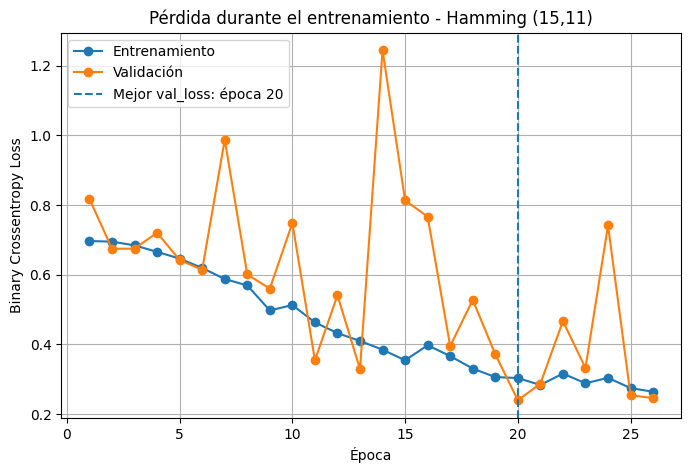

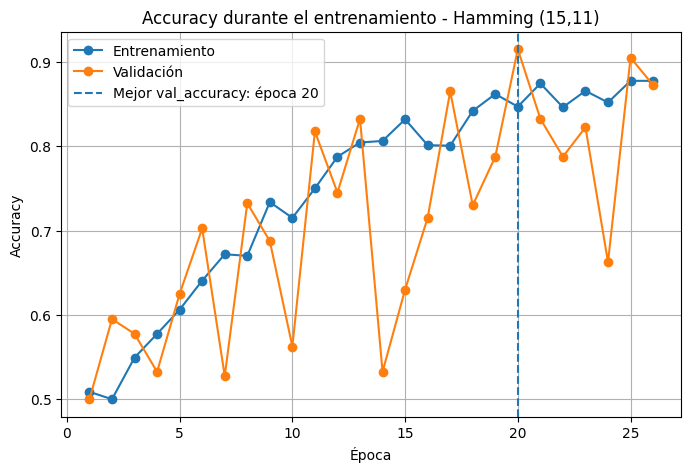

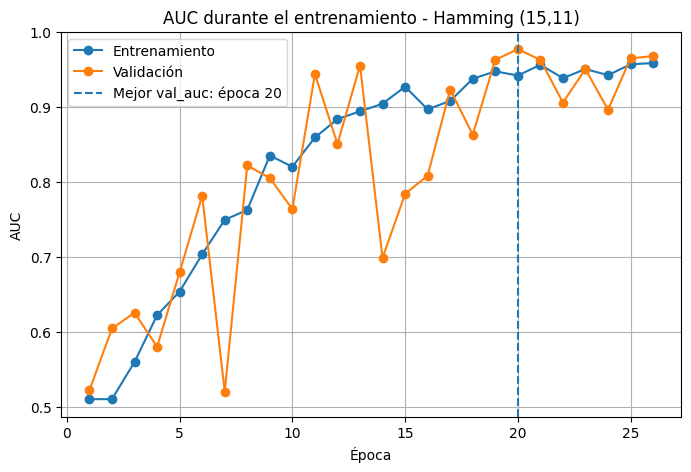


DIAGNÓSTICO DE SOBREAJUSTE: Hamming (15,11)
Mejor época según val_loss: 20
Mejor val_loss: 0.2393
Última train_loss: 0.2637
Última val_loss: 0.2454
Aumento relativo de val_loss respecto al mejor punto: 2.54%

Accuracy final:
Train accuracy: 0.8775
Val accuracy:   0.8725
Brecha train - val accuracy: 0.0050

AUC final:
Train AUC: 0.9583
Val AUC:   0.9677
Brecha train - val AUC: -0.0093

Interpretación:
No hay señales fuertes de sobreajuste.
El entrenamiento y la validación se comportan de forma relativamente similar.


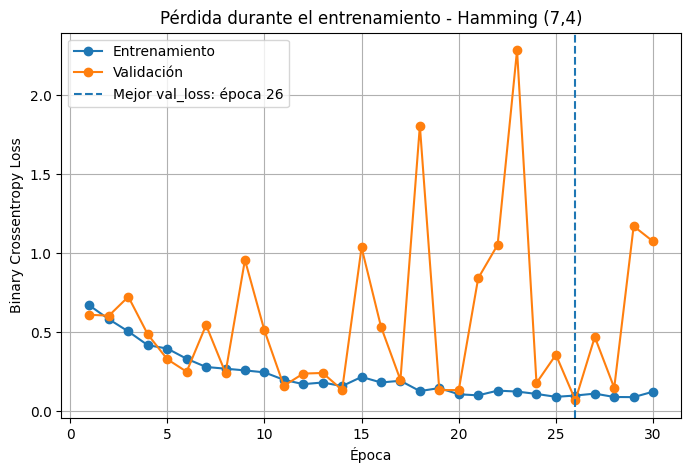

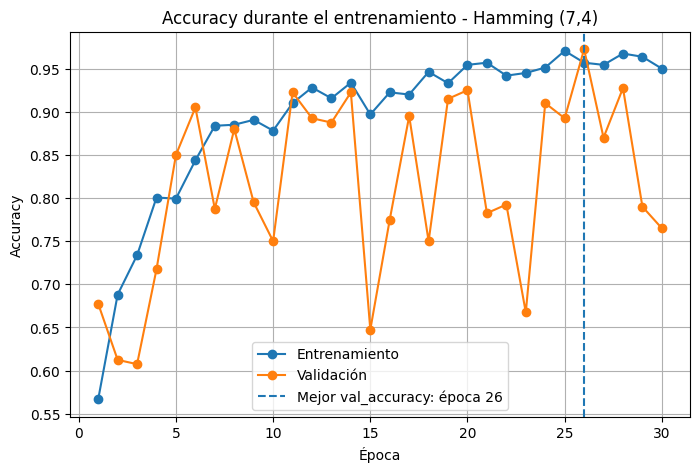

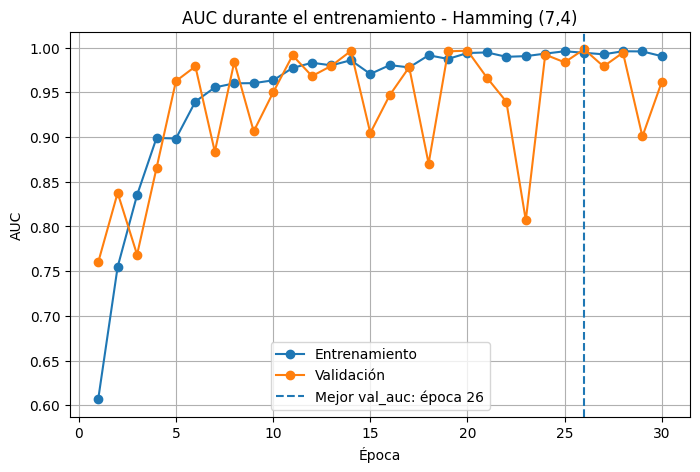


DIAGNÓSTICO DE SOBREAJUSTE: Hamming (7,4)
Mejor época según val_loss: 26
Mejor val_loss: 0.0705
Última train_loss: 0.1247
Última val_loss: 1.0751
Aumento relativo de val_loss respecto al mejor punto: 1424.17%

Accuracy final:
Train accuracy: 0.9500
Val accuracy:   0.7650
Brecha train - val accuracy: 0.1850

AUC final:
Train AUC: 0.9903
Val AUC:   0.9618
Brecha train - val AUC: 0.0285

Interpretación:
Hay señales claras de SOBREAJUSTE.
El modelo mejora en entrenamiento, pero pierde generalización en validación.


In [36]:
# ============================================================
# DIAGNÓSTICO DE SOBREAJUSTE Y CURVAS DE ENTRENAMIENTO
# ============================================================

def graficar_curvas_entrenamiento(historial, nombre_modelo):
    hist = historial.history
    epocas = range(1, len(hist["loss"]) + 1)

    # ----------------------------
    # Gráfica de pérdida
    # ----------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(epocas, hist["loss"], marker="o", label="Entrenamiento")
    plt.plot(epocas, hist["val_loss"], marker="o", label="Validación")

    mejor_epoca_loss = np.argmin(hist["val_loss"]) + 1
    mejor_val_loss = np.min(hist["val_loss"])

    plt.axvline(
        mejor_epoca_loss,
        linestyle="--",
        label=f"Mejor val_loss: época {mejor_epoca_loss}"
    )

    plt.title(f"Pérdida durante el entrenamiento - {nombre_modelo}")
    plt.xlabel("Época")
    plt.ylabel("Binary Crossentropy Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ----------------------------
    # Gráfica de accuracy
    # ----------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(epocas, hist["accuracy"], marker="o", label="Entrenamiento")
    plt.plot(epocas, hist["val_accuracy"], marker="o", label="Validación")

    mejor_epoca_acc = np.argmax(hist["val_accuracy"]) + 1
    mejor_val_acc = np.max(hist["val_accuracy"])

    plt.axvline(
        mejor_epoca_acc,
        linestyle="--",
        label=f"Mejor val_accuracy: época {mejor_epoca_acc}"
    )

    plt.title(f"Accuracy durante el entrenamiento - {nombre_modelo}")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ----------------------------
    # Gráfica de AUC, si existe
    # ----------------------------
    if "auc" in hist and "val_auc" in hist:
        plt.figure(figsize=(8, 5))
        plt.plot(epocas, hist["auc"], marker="o", label="Entrenamiento")
        plt.plot(epocas, hist["val_auc"], marker="o", label="Validación")

        mejor_epoca_auc = np.argmax(hist["val_auc"]) + 1
        mejor_val_auc = np.max(hist["val_auc"])

        plt.axvline(
            mejor_epoca_auc,
            linestyle="--",
            label=f"Mejor val_auc: época {mejor_epoca_auc}"
        )

        plt.title(f"AUC durante el entrenamiento - {nombre_modelo}")
        plt.xlabel("Época")
        plt.ylabel("AUC")
        plt.legend()
        plt.grid(True)
        plt.show()


def diagnosticar_sobreajuste(historial, nombre_modelo):
    hist = historial.history

    train_loss = np.array(hist["loss"])
    val_loss = np.array(hist["val_loss"])

    train_acc = np.array(hist["accuracy"])
    val_acc = np.array(hist["val_accuracy"])

    mejor_epoca_val_loss = np.argmin(val_loss)
    mejor_val_loss = val_loss[mejor_epoca_val_loss]

    ultima_train_loss = train_loss[-1]
    ultima_val_loss = val_loss[-1]

    ultima_train_acc = train_acc[-1]
    ultima_val_acc = val_acc[-1]

    gap_acc = ultima_train_acc - ultima_val_acc

    aumento_val_loss = (ultima_val_loss - mejor_val_loss) / abs(mejor_val_loss)

    print("\n" + "="*70)
    print(f"DIAGNÓSTICO DE SOBREAJUSTE: {nombre_modelo}")
    print("="*70)

    print(f"Mejor época según val_loss: {mejor_epoca_val_loss + 1}")
    print(f"Mejor val_loss: {mejor_val_loss:.4f}")
    print(f"Última train_loss: {ultima_train_loss:.4f}")
    print(f"Última val_loss: {ultima_val_loss:.4f}")
    print(f"Aumento relativo de val_loss respecto al mejor punto: {aumento_val_loss*100:.2f}%")

    print("\nAccuracy final:")
    print(f"Train accuracy: {ultima_train_acc:.4f}")
    print(f"Val accuracy:   {ultima_val_acc:.4f}")
    print(f"Brecha train - val accuracy: {gap_acc:.4f}")

    if "auc" in hist and "val_auc" in hist:
        train_auc = np.array(hist["auc"])
        val_auc = np.array(hist["val_auc"])

        ultima_train_auc = train_auc[-1]
        ultima_val_auc = val_auc[-1]
        gap_auc = ultima_train_auc - ultima_val_auc

        print("\nAUC final:")
        print(f"Train AUC: {ultima_train_auc:.4f}")
        print(f"Val AUC:   {ultima_val_auc:.4f}")
        print(f"Brecha train - val AUC: {gap_auc:.4f}")
    else:
        gap_auc = 0

    print("\nInterpretación:")

    if aumento_val_loss > 0.10 and (gap_acc > 0.08 or gap_auc > 0.08):
        print("Hay señales claras de SOBREAJUSTE.")
        print("El modelo mejora en entrenamiento, pero pierde generalización en validación.")

    elif gap_acc > 0.10 or gap_auc > 0.10:
        print("Hay posible SOBREAJUSTE.")
        print("La diferencia entre entrenamiento y validación es alta.")

    elif ultima_train_acc < 0.60 and ultima_val_acc < 0.60:
        print("No parece sobreajuste fuerte.")
        print("El problema parece más cercano a underfitting, colapso de clase o señal esteganográfica muy débil.")

    else:
        print("No hay señales fuertes de sobreajuste.")
        print("El entrenamiento y la validación se comportan de forma relativamente similar.")


# ============================================================
# EJECUTAR DIAGNÓSTICO PARA AMBOS MODELOS
# ============================================================

graficar_curvas_entrenamiento(
    historial,
    "Hamming (15,11)"
)

diagnosticar_sobreajuste(
    historial,
    "Hamming (15,11)"
)

graficar_curvas_entrenamiento(
    historial_7,
    "Hamming (7,4)"
)

diagnosticar_sobreajuste(
    historial_7,
    "Hamming (7,4)"
)

In [37]:
# ============================================================
# EVALUACIÓN FINAL: TRAIN VS VALIDATION EN PYTORCH
# ============================================================

def evaluar_train_vs_val(modelo, train_ds, val_ds, nombre_modelo):
    print("\n" + "="*70)
    print(f"EVALUACIÓN FINAL TRAIN VS VALIDATION: {nombre_modelo}")
    print("="*70)

    criterio = nn.BCEWithLogitsLoss()

    resultados_train = evaluar_modelo_pytorch(
        modelo,
        train_ds,
        criterio
    )

    resultados_val = evaluar_modelo_pytorch(
        modelo,
        val_ds,
        criterio
    )

    print("\nResultados en entrenamiento:")
    for metrica, valor in resultados_train.items():
        print(f"{metrica}: {valor:.4f}")

    print("\nResultados en validación:")
    for metrica, valor in resultados_val.items():
        print(f"{metrica}: {valor:.4f}")

    print("\nBrechas train - validation:")
    for metrica in resultados_train.keys():
        brecha = resultados_train[metrica] - resultados_val[metrica]
        print(f"{metrica}: {brecha:.4f}")

    if "accuracy" in resultados_train and "accuracy" in resultados_val:
        gap_accuracy = resultados_train["accuracy"] - resultados_val["accuracy"]

        if gap_accuracy > 0.10:
            print("\nALERTA: posible sobreajuste por brecha alta en accuracy.")

    if "auc" in resultados_train and "auc" in resultados_val:
        gap_auc = resultados_train["auc"] - resultados_val["auc"]

        if gap_auc > 0.10:
            print("\nALERTA: posible sobreajuste por brecha alta en AUC.")


evaluar_train_vs_val(
    model_resnet,
    train_dataset,
    val_dataset,
    "Hamming (15,11)"
)

evaluar_train_vs_val(
    modelo_resnet_7,
    train_dataset_7,
    val_dataset_7,
    "Hamming (7,4)"
)



EVALUACIÓN FINAL TRAIN VS VALIDATION: Hamming (15,11)


C:\Users\m.amorocho\AppData\Local\Temp\1\ipykernel_472\1952804830.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USAR_AMP):
C:\Users\m.amorocho\AppData\Local\Temp\1\ipykernel_472\1952804830.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USAR_AMP):



Resultados en entrenamiento:
loss: 0.2637
accuracy: 0.9156
auc: 0.9747

Resultados en validación:
loss: 0.2393
accuracy: 0.9150
auc: 0.9768

Brechas train - validation:
loss: 0.0243
accuracy: 0.0006
auc: -0.0020

EVALUACIÓN FINAL TRAIN VS VALIDATION: Hamming (7,4)


C:\Users\m.amorocho\AppData\Local\Temp\1\ipykernel_472\1952804830.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USAR_AMP):
C:\Users\m.amorocho\AppData\Local\Temp\1\ipykernel_472\1952804830.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USAR_AMP):



Resultados en entrenamiento:
loss: 0.0699
accuracy: 0.9738
auc: 0.9984

Resultados en validación:
loss: 0.0705
accuracy: 0.9725
auc: 0.9981

Brechas train - validation:
loss: -0.0007
accuracy: 0.0012
auc: 0.0003


# **Fase 4: Evaluación y Discusión**

## **4.1. Evaluación de Fidelidad Visual (Métricas de Calidad)**

Para medir el impacto del *Matrix Embedding* en las imágenes de cobertura, se emplearon dos métricas estándar en el procesamiento de imágenes esteganográficas:

1. PSNR (Peak Signal-to-Noise Ratio): Mide la relación entre el máximo valor posible de un píxel y el ruido introducido por el ocultamiento (Error Cuadrático Medio o MSE). Se expresa en decibelios (dB). Un valor más alto indica una menor degradación visual. Su formulación matemática es:

$$MSE = \frac{1}{m\,n} \sum_{i=0}^{m-1} \sum_{j=0}^{n-1} [I(i,j) - K(i,j)]^2$$
$$PSNR = 10 \cdot \log_{10} \left( \frac{MAX_I^2}{MSE} \right)$$

2. SSIM (Structural Similarity Index Measure): A diferencia del PSNR, que mide el error absoluto, el SSIM evalúa la degradación de la estructura espacial de la imagen, modelando mejor la percepción del ojo humano. Sus valores oscilan entre $-1$ y $1$, donde $1$ indica una imagen idéntica a la original.

Se espera que el esquema basado en Hamming (15,11) reporte valores de PSNR y SSIM superiores a los de Hamming (7,4) bajo tasas de payload equivalentes, debido a su menor tasa de modificación de píxeles esperada.



In [38]:
# Rutas de los directorios usando el dataset ya existente
dir_cover = directorio_cover
dir_stego_7 = directorio_stego_7
dir_stego_15 = directorio_stego_15

def evaluar_dataset(ruta_cover, ruta_stego, limite=100):
    """
    Compara un conjunto de imágenes limpias vs estego y retorna el promedio de PSNR y SSIM.
    Se utiliza un límite para evaluar una muestra representativa y agilizar el cómputo.
    """
    imagenes_cover = sorted(glob.glob(os.path.join(ruta_cover, '*.png')))[:limite]

    lista_psnr = []
    lista_ssim = []

    for path_cov in imagenes_cover:
        nombre_archivo = os.path.basename(path_cov)
        path_stg = os.path.join(ruta_stego, nombre_archivo)

        if not os.path.exists(path_stg):
            continue

        # Cargar imágenes
        img_cov = cv2.imread(path_cov, cv2.IMREAD_GRAYSCALE)
        img_stg = cv2.imread(path_stg, cv2.IMREAD_GRAYSCALE)

        if img_cov is None or img_stg is None:
            continue

        # Calcular métricas
        val_psnr = compute_psnr(img_cov, img_stg, data_range=255)
        val_ssim = compute_ssim(img_cov, img_stg, data_range=255, win_size=11)

        lista_psnr.append(val_psnr)
        lista_ssim.append(val_ssim)

    return np.mean(lista_psnr), np.mean(lista_ssim)


In [39]:
# Evaluamos una muestra estocástica (ej. 100 imágenes) para obtener significancia estadística
MUESTRAS_EVALUACION = 100

psnr_7, ssim_7 = evaluar_dataset(dir_cover, dir_stego_7, limite=MUESTRAS_EVALUACION)
psnr_15, ssim_15 = evaluar_dataset(dir_cover, dir_stego_15, limite=MUESTRAS_EVALUACION)

print(f"\nResultados Promedio sobre {MUESTRAS_EVALUACION} imágenes:")
print("-" * 50)
print(f"Esquema Hamming (7,4):")
print(f" -> PSNR Promedio: {psnr_7:.2f} dB")
print(f" -> SSIM Promedio: {ssim_7:.4f}")
print("-" * 50)
print(f"Esquema Hamming (15,11):")
print(f" -> PSNR Promedio: {psnr_15:.2f} dB")
print(f" -> SSIM Promedio: {ssim_15:.4f}")
print("-" * 50)

# Verificación de hipótesis de tu documento
if psnr_15 > psnr_7:
    print("\n[ÉXITO] La hipótesis se confirma: Hamming (15,11) presenta menor distorsión visual (Mayor PSNR).")


Resultados Promedio sobre 100 imágenes:
--------------------------------------------------
Esquema Hamming (7,4):
 -> PSNR Promedio: 57.16 dB
 -> SSIM Promedio: 0.9992
--------------------------------------------------
Esquema Hamming (15,11):
 -> PSNR Promedio: 60.17 dB
 -> SSIM Promedio: 0.9996
--------------------------------------------------

[ÉXITO] La hipótesis se confirma: Hamming (15,11) presenta menor distorsión visual (Mayor PSNR).


## **4.2. Evaluación de la Red Residual (Métricas de Clasificación)**

Para cuantificar la capacidad de detección del modelo estegoanalítico (ResNet) sobre datos no vistos previamente, se extraen las predicciones probabilísticas utilizando el subconjunto de validación. El desempeño se evalúa mediante dos herramientas estadísticas fundamentales:

1. Matriz de Confusión: Permite visualizar la distribución de los aciertos y errores topológicos del modelo. En el contexto del esteganálisis, resulta crítico analizar la tasa de Falsos Negativos (imágenes con esteganografía que el modelo clasifica erróneamente como limpias), ya que esta métrica cuantifica directamente el nivel de "evasión" exitosa logrado por el algoritmo de Matrix Embedding.

2. Curva ROC (Receiver Operating Characteristic) y AUC (Area Under the Curve): La curva ROC grafica la relación entre la Tasa de Verdaderos Positivos (TPR) y la Tasa de Falsos Positivos (FPR) a través de múltiples umbrales de decisión. El valor del área bajo la curva ($AUC \in [0, 1]$) resume el rendimiento global del clasificador. Un $AUC \approx 0.5$ indica una detección aleatoria (lo que implicaría un esteganálisis fallido y un ocultamiento perfecto), mientras que un $AUC$ cercano a $1.0$ representa una clasificación perfecta.

In [40]:
print("--- Extrayendo predicciones comparativas de los modelos PyTorch ---")

def obtener_predicciones(modelo, dataset_val):
    """Extrae las etiquetas reales y las predicciones de probabilidad de un DataLoader de PyTorch."""
    modelo.eval()
    y_real = []
    y_pred_prob = []

    with torch.no_grad():
        for img, label in dataset_val:
            img = img.to(device, non_blocking=True)

            with autocast(enabled=USAR_AMP):
                logits = modelo(img)

            preds = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
            labels = label.detach().cpu().numpy().reshape(-1)

            y_real.extend(labels)
            y_pred_prob.extend(preds)

    return np.array(y_real), np.array(y_pred_prob).flatten()


--- Extrayendo predicciones comparativas de los modelos PyTorch ---


In [41]:
# ============================================================
# DIAGNÓSTICO DE COLAPSO DE CLASE
# ============================================================

def diagnosticar_predicciones(nombre, y_real, y_prob):
    y_real = y_real.reshape(-1).astype(int)
    y_prob = y_prob.reshape(-1)

    y_bin = (y_prob > 0.5).astype(int)

    print("\n" + "="*60)
    print(f"DIAGNÓSTICO: {nombre}")
    print("="*60)

    print(f"Clases reales:")
    print(f"  Cover  (0): {np.sum(y_real == 0)}")
    print(f"  Stego  (1): {np.sum(y_real == 1)}")

    print(f"\nPredicciones binarias con umbral 0.5:")
    print(f"  Predicho Cover (0): {np.sum(y_bin == 0)}")
    print(f"  Predicho Stego (1): {np.sum(y_bin == 1)}")

    print(f"\nProbabilidades:")
    print(f"  Media: {y_prob.mean():.4f}")
    print(f"  Mínima: {y_prob.min():.4f}")
    print(f"  Máxima: {y_prob.max():.4f}")
    print(f"  Desviación estándar: {y_prob.std():.4f}")

    if np.all(y_bin == 0):
        print("\nALERTA: el modelo está prediciendo TODO como cover.")
    elif np.all(y_bin == 1):
        print("\nALERTA: el modelo está prediciendo TODO como stego.")
    else:
        print("\nOK: el modelo está usando ambas clases.")

In [42]:
y_real_15, y_prob_15 = obtener_predicciones(model_resnet, val_dataset)
y_real_7, y_prob_7 = obtener_predicciones(modelo_resnet_7, val_dataset_7)

diagnosticar_predicciones("Hamming (15,11)", y_real_15, y_prob_15)
diagnosticar_predicciones("Hamming (7,4)", y_real_7, y_prob_7)

C:\Users\m.amorocho\AppData\Local\Temp\1\ipykernel_472\3374269389.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USAR_AMP):



DIAGNÓSTICO: Hamming (15,11)
Clases reales:
  Cover  (0): 200
  Stego  (1): 200

Predicciones binarias con umbral 0.5:
  Predicho Cover (0): 190
  Predicho Stego (1): 210

Probabilidades:
  Media: 0.5068
  Mínima: 0.0007
  Máxima: 1.0000
  Desviación estándar: 0.3801

OK: el modelo está usando ambas clases.

DIAGNÓSTICO: Hamming (7,4)
Clases reales:
  Cover  (0): 200
  Stego  (1): 200

Predicciones binarias con umbral 0.5:
  Predicho Cover (0): 191
  Predicho Stego (1): 209

Probabilidades:
  Media: 0.5186
  Mínima: 0.0000
  Máxima: 1.0000
  Desviación estándar: 0.4673

OK: el modelo está usando ambas clases.


In [43]:
# 1. Obtener datos para Hamming (15,11) - Usando tu variable corregida
y_real_15, y_prob_15 = obtener_predicciones(model_resnet, val_dataset)

# 2. Obtener datos para Hamming (7,4)
y_real_7, y_prob_7 = obtener_predicciones(modelo_resnet_7, val_dataset_7)

# 3. Binarización mediante Umbral estándar (0.5)
y_bin_15 = (y_prob_15 > 0.5).astype(int)
y_bin_7 = (y_prob_7 > 0.5).astype(int)

cm_15 = confusion_matrix(y_real_15, y_bin_15)
cm_7 = confusion_matrix(y_real_7, y_bin_7)
# 4. Cálculo de coordenadas para las Curvas ROC y AUC
fpr_15, tpr_15, _ = roc_curve(y_real_15, y_prob_15)
auc_15 = auc(fpr_15, tpr_15)

fpr_7, tpr_7, _ = roc_curve(y_real_7, y_prob_7)
auc_7 = auc(fpr_7, tpr_7)

C:\Users\m.amorocho\AppData\Local\Temp\1\ipykernel_472\3374269389.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USAR_AMP):


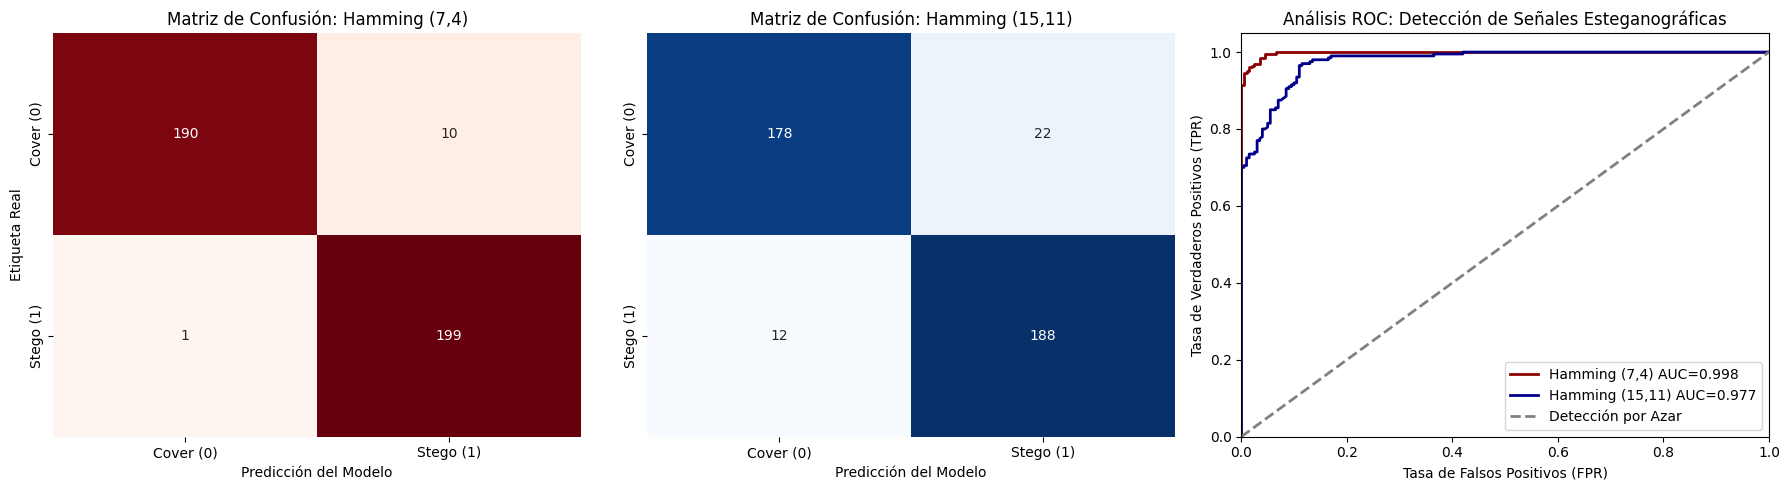

In [44]:
# --- 5. DIAGRAMACIÓN VISUAL UNIFICADA ---
plt.figure(figsize=(18, 5))

# Subplot 1: Matriz de Confusión 7,4 (Tonos Rojos para diferenciar)
plt.subplot(1, 3, 1)
sns.heatmap(cm_7, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Cover (0)', 'Stego (1)'],
            yticklabels=['Cover (0)', 'Stego (1)'])
plt.title('Matriz de Confusión: Hamming (7,4)')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')

# Subplot 2: Matriz de Confusión 15,11 (Tonos Azules)
plt.subplot(1, 3, 2)
sns.heatmap(cm_15, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Cover (0)', 'Stego (1)'],
            yticklabels=['Cover (0)', 'Stego (1)'])
plt.title('Matriz de Confusión: Hamming (15,11)')
plt.xlabel('Predicción del Modelo')

# Subplot 3: Curvas ROC Superpuestas
plt.subplot(1, 3, 3)
plt.plot(fpr_7, tpr_7, color='darkred', lw=2, label=f'Hamming (7,4) AUC={auc_7:.3f}')
plt.plot(fpr_15, tpr_15, color='darkblue', lw=2, label=f'Hamming (15,11) AUC={auc_15:.3f}')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Detección por Azar')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Análisis ROC: Detección de Señales Esteganográficas')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [45]:
# --- 6. Análisis Estadístico de Evasión ---
fn_7 = cm_7[1, 0]
total_7 = np.sum(cm_7[1, :])
tasa_evasion_7 = (fn_7 / total_7) * 100 if total_7 > 0 else 0

fn_15 = cm_15[1, 0]
total_15 = np.sum(cm_15[1, :])
tasa_evasion_15 = (fn_15 / total_15) * 100 if total_15 > 0 else 0

print("\n" + "="*50)
print("RESUMEN ESTADÍSTICO DE EVASIÓN ESTEGANOGRÁFICA")
print("="*50)
print(f"Esquema (7,4)   - Falsos Negativos: {fn_7}/{total_7} -> Tasa de Evasión: {tasa_evasion_7:.2f}%")
print(f"Esquema (15,11) - Falsos Negativos: {fn_15}/{total_15} -> Tasa de Evasión: {tasa_evasion_15:.2f}%")
print("-" * 50)

if tasa_evasion_15 > tasa_evasion_7:
    print("CONCLUSIÓN: Hipótesis confirmada. El esquema (15,11) es criptográficamente")
    print("más robusto y presenta mayor dificultad de detección forense.")
else:
    print("CONCLUSIÓN: El factor de regularización de la red mitigó el ruido en ambos")
    print("esquemas, logrando tasas de detección similares.")


RESUMEN ESTADÍSTICO DE EVASIÓN ESTEGANOGRÁFICA
Esquema (7,4)   - Falsos Negativos: 1/200 -> Tasa de Evasión: 0.50%
Esquema (15,11) - Falsos Negativos: 12/200 -> Tasa de Evasión: 6.00%
--------------------------------------------------
CONCLUSIÓN: Hipótesis confirmada. El esquema (15,11) es criptográficamente
más robusto y presenta mayor dificultad de detección forense.
